In [1]:
import os
import sys

sys.path.insert(
    0, os.path.abspath("../../")
)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegressionCV, LogisticRegression

In [2]:
root_dir = Path("../../").resolve()
print(">> Root directory:", root_dir)

>> Root directory: /home/hgkahng/Workspaces/soft-prompt


# 1. Load Oracle Data

### 1-1. Load Embeddings

In [3]:
data_dir = root_dir / "data/emotion"
embedding_dir = data_dir / "embeddings/openai/text-embedding-3-small"
print(*sorted(os.listdir(embedding_dir)), sep='\n')

test.features.npy
test.labels.npy
train.features.npy
train.labels.npy
unsplit.features.npy
unsplit.labels.npy
validation.features.npy
validation.labels.npy


In [4]:
X_train = np.load(embedding_dir / "train.features.npy")
y_train = np.load(embedding_dir / "train.labels.npy")
print(X_train.shape, y_train.shape)

(16000, 1536) (16000,)


In [5]:
X_val = np.load(embedding_dir / "validation.features.npy")
y_val = np.load(embedding_dir / "validation.labels.npy")
print(X_val.shape, y_val.shape)

(2000, 1536) (2000,)


In [6]:
X_test = np.load(embedding_dir / "test.features.npy")
y_test = np.load(embedding_dir / "test.labels.npy")
print(X_test.shape, y_test.shape)

(2000, 1536) (2000,)


In [7]:
X_unsplit = np.load(embedding_dir / "unsplit.features.npy")
y_unsplit = np.load(embedding_dir / "unsplit.labels.npy")
print(X_unsplit.shape, y_unsplit.shape)

(416809, 1536) (416809,)


### 1-2. Load Text

`split`

In [14]:
from datasets import load_dataset
ds = load_dataset("dair-ai/emotion", "split", cache_dir="../../.cache/")

In [16]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [19]:
_ = ds['train']['text'] + ds['validation']['text'] + ds['test']['text']

`unsplit`

In [20]:
ds_unsplit = load_dataset("dair-ai/emotion", "unsplit", cache_dir="../../.cache/")
ds_unsplit

train-00000-of-00001.parquet:   0%|          | 0.00/26.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/416809 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 416809
    })
})

## 2. Diversity Metrics
- For simplicity, let's use the `split` split.

In [21]:
from softprompt.metrics.diversity import (
    vocabulary_size,
    distinct_n,
    average_pairwise_similarity,
    average_pairwise_similarity_by_class,
    inter_sample_ngram_freq
)

In [26]:
labels = np.concatenate([y_train, y_val, y_test], axis=0)
print(labels.shape[0])

texts = ds['train']['text'] + ds['validation']['text'] + ds['test']['text']
print(len(texts))

embeddings = np.concatenate([X_train, X_val, X_test], axis=0)
print(embeddings.shape)

20000
20000
(20000, 1536)


In [27]:
vocab_size = vocabulary_size(texts)
print(f"Vocab: {vocab_size:>7,}")

Vocab:  17,094


In [28]:
distinct_2 = distinct_n(texts, n=2)
print(f"Distinct-2: {distinct_2:.4f}")

Distinct-2: 0.3486


In [29]:
%%time
inter_sim, intra_sim = average_pairwise_similarity_by_class(
    embeddings, labels
)
print(f"Inter-class APS: {inter_sim:.4f}\n",
      f"Intra-class APS: {intra_sim:.4f}")

Inter-class APS: 0.2665
 Intra-class APS: 0.2874
CPU times: user 32.3 s, sys: 15.5 s, total: 47.7 s
Wall time: 3.49 s


In [30]:
%%time
avg_ps = average_pairwise_similarity(embeddings)
print(f"Avg Pairwise Similarity: {avg_ps:.4f}")

Avg Pairwise Similarity: 0.2715
CPU times: user 29 s, sys: 14.4 s, total: 43.4 s
Wall time: 3.26 s


In [31]:
del labels, texts, embeddings  # no further use

# 2. Classification Performance (Imbalanced)

In [10]:
from sklearn.metrics import f1_score, accuracy_score

def evaluate_lg(X_train: np.ndarray,
                y_train: np.ndarray,
                X_test: np.ndarray,
                y_test: np.ndarray,
                subsample_size: int = 1000,
                bootstrap: bool = True,  # sampling with replacement
                n_trials: int = 50,
                penalty="l2",  # or None
                n_jobs=16,) -> dict[str, tuple[float, float]]:

    assert X_train.shape[0] == len(y_train)

    train_acc_array = np.empty(n_trials)
    test_acc_array = np.empty_like(train_acc_array)
    train_f1_array = np.empty(n_trials)
    test_f1_array = np.empty_like(train_f1_array)
    
    original_idx = np.arange(X_train.shape[0])  # [0, 1, ..., len(X_train)]

    for i in range(n_trials):
        
        # get indices to use for training
        rng = np.random.default_rng(42+i)
        if bootstrap:
            use_idx = rng.choice(original_idx, size=subsample_size, replace=True)
        else:
            shuffled_idx = rng.permutation(original_idx)
            use_idx = shuffled_idx[:subsample_size]

        # fit model
        lg_kwargs = {"solver": "lbfgs", "max_iter": 1_000, "n_jobs": n_jobs,
                     "random_state": 42+i, }
        if penalty == 'l2':
            lg = LogisticRegressionCV(Cs=10, cv=5, penalty='l2', scoring='neg_log_loss',
                                      **lg_kwargs)                            
        elif penalty is None:
            lg = LogisticRegression(penalty=None, **lg_kwargs)
        else:
            raise NotImplementedError

        lg.fit(X_train[use_idx], y_train[use_idx]);

        # evaluate (simple accuracy)
        train_acc_array[i] = \
            accuracy_score(y_train[use_idx], lg.predict(X_train[use_idx]))
        test_acc_array[i] = \
            accuracy_score(y_test, lg.predict(X_test))
        
        # evaluate (f1)
        train_f1_array[i] = \
            f1_score(y_train[use_idx], lg.predict(X_train[use_idx]), average='macro')
        test_f1_array[i] = \
            f1_score(y_test, lg.predict(X_test), average='macro')

    return {
        'train_accuracy': (train_acc_array.mean(), train_acc_array.std(ddof=1)),
        'test_accuracy': (test_acc_array.mean(), test_acc_array.std(ddof=1)),
        'train_f1': (train_f1_array.mean(), train_f1_array.std(ddof=1)),
        'test_f1': (test_f1_array.mean(), test_f1_array.std(ddof=1)),
    }

### 2-1. Without regularization
- `LogisticRegression(penalty=None)`

In [ ]:
size_to_acc = {}
subsample_sizes = [int(len(X_train) * r) for r in (0.01, 0.05, 0.10, 0.25, 0.5, 1.0)]

for i, subsample_size in enumerate(subsample_sizes):
    print(f">> No Regularization")
    print(f">> Sample size: {subsample_size:>6,}")

    eval_result = evaluate_lg(
        X_train, y_train, X_test, y_test,
        subsample_size=subsample_size,
        bootstrap=False,
        n_trials=5,
        penalty=None,
    )

    train_acc, test_acc = \
        eval_result['train_accuracy'], eval_result['test_accuracy']
    train_f1, test_f1 = \
        eval_result['train_f1'], eval_result['test_f1']

    size_to_acc[subsample_size] = eval_result

    print("\t Train acc = {:.4f} ({:.4f})".format(*train_acc))
    print("\t  Test acc = {:.4f} ({:.4f})".format(*test_acc))
    print("\t Train  f1 = {:.4f} ({:.4f})".format(*train_f1))
    print("\t  Test  f1 = {:.4f} ({:.4f})".format(*test_f1))

### 2-2. With Regularization
- `LogisticRegressionCV(Cs=10, cv=5, penalty='l2')`

In [20]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [22]:
size_to_acc = {}
subsample_sizes = [int(len(X_train) * r) for r in (0.25, 0.5, 1.0)]

for i, subsample_size in enumerate(subsample_sizes):
    print(f">> With Regularization")
    print(f">> Sample size: {subsample_size:>6,}")

    eval_result = evaluate_lg(
        X_train, y_train, X_test, y_test,
        subsample_size=subsample_size,
        bootstrap=False,
        n_trials=5,
        penalty='l2',
    )

    train_acc, test_acc = \
        eval_result['train_accuracy'], eval_result['test_accuracy']
    train_f1, test_f1 = \
        eval_result['train_f1'], eval_result['test_f1']

    size_to_acc[subsample_size] = eval_result

    print("\t Train acc = {:.4f} ({:.4f})".format(*train_acc))
    print("\t  Test acc = {:.4f} ({:.4f})".format(*test_acc))
    print("\t Train  f1 = {:.4f} ({:.4f})".format(*train_f1))
    print("\t  Test  f1 = {:.4f} ({:.4f})".format(*test_f1))

>> With Regularization
>> Sample size:  4,000


	 Train acc = 0.8374 (0.0043)
	  Test acc = 0.7240 (0.0064)
	 Train  f1 = 0.8001 (0.0106)
	  Test  f1 = 0.6337 (0.0100)
>> With Regularization
>> Sample size:  8,000
	 Train acc = 0.8447 (0.0364)
	  Test acc = 0.7508 (0.0055)
	 Train  f1 = 0.8087 (0.0500)
	  Test  f1 = 0.6779 (0.0058)
>> With Regularization
>> Sample size: 16,000
	 Train acc = 0.8864 (0.0013)
	  Test acc = 0.7844 (0.0002)
	 Train  f1 = 0.8687 (0.0020)
	  Test  f1 = 0.7214 (0.0014)


## 3. Classification Performance (Balanced)
- Train on the `unsplit` set, and evaluate predictive performance on the `split` set.
- Label distribution is balanced by undersampling each label's sample count to that of the minority class.

In [23]:
minority_class_count: int = pd.Series(y_unsplit).value_counts(normalize=False).min()
print(f"Sample size of minority class: {minority_class_count:,}")

Sample size of minority class: 14,972


In [24]:
undersampling_idx = []
rng = np.random.default_rng(42)
for c in np.unique(y_unsplit):               # 0, 1, 2, 3, 4, 5 
    class_idx = np.where(y_unsplit == c)[0]  # gather indices of data points with label == c
    class_idx = rng.choice(class_idx, size=minority_class_count, replace=False)  # downsample
    undersampling_idx.append(class_idx)

undersampling_idx = np.concatenate(undersampling_idx, axis=0)

In [25]:
X_unsplit_undersampled = X_unsplit[undersampling_idx]
y_unsplit_undersampled = y_unsplit[undersampling_idx]

In [26]:
pd.Series(y_unsplit_undersampled).value_counts()

0    14972
1    14972
2    14972
3    14972
4    14972
5    14972
Name: count, dtype: int64

In [30]:
len(X_unsplit_undersampled)

89832

In [28]:
X_split = np.concatenate([X_train, X_val, X_test], axis=0)
y_split = np.concatenate([y_train, y_val, y_test], axis=0)
print(X_split.shape, y_split.shape)

(20000, 1536) (20000,)


### 3-1. Without Regularization
- `LogisticRegression(penalty=None)`

#### 3-1-1. Fit model on the whole undersampled data
- Size: $14792 \times 6$

In [29]:
# On full-size training data
lg = LogisticRegression(penalty=None,
                        solver='lbfgs',
                        max_iter=10000,
                        random_state=42)
lg.fit(X_unsplit_undersampled, y_unsplit_undersampled);

Unsplit (Train) (downsampled):
              precision    recall  f1-score   support

     sadness     0.8296    0.8223    0.8259     14972
         joy     0.8104    0.7754    0.7925     14972
        love     0.8225    0.8446    0.8334     14972
       anger     0.8522    0.8565    0.8544     14972
        fear     0.8272    0.8118    0.8194     14972
    surprise     0.8674    0.9007    0.8837     14972

    accuracy                         0.8352     89832
   macro avg     0.8349    0.8352    0.8349     89832
weighted avg     0.8349    0.8352    0.8349     89832

Split (Test):
              precision    recall  f1-score   support

     sadness     0.8782    0.8037    0.8393      5797
         joy     0.9119    0.7503    0.8233      6761
        love     0.5604    0.8397    0.6722      1641
       anger     0.7661    0.8464    0.8043      2709
        fear     0.7414    0.7779    0.7592      2373
    surprise     0.5513    0.9124    0.6873       719

    accuracy                    

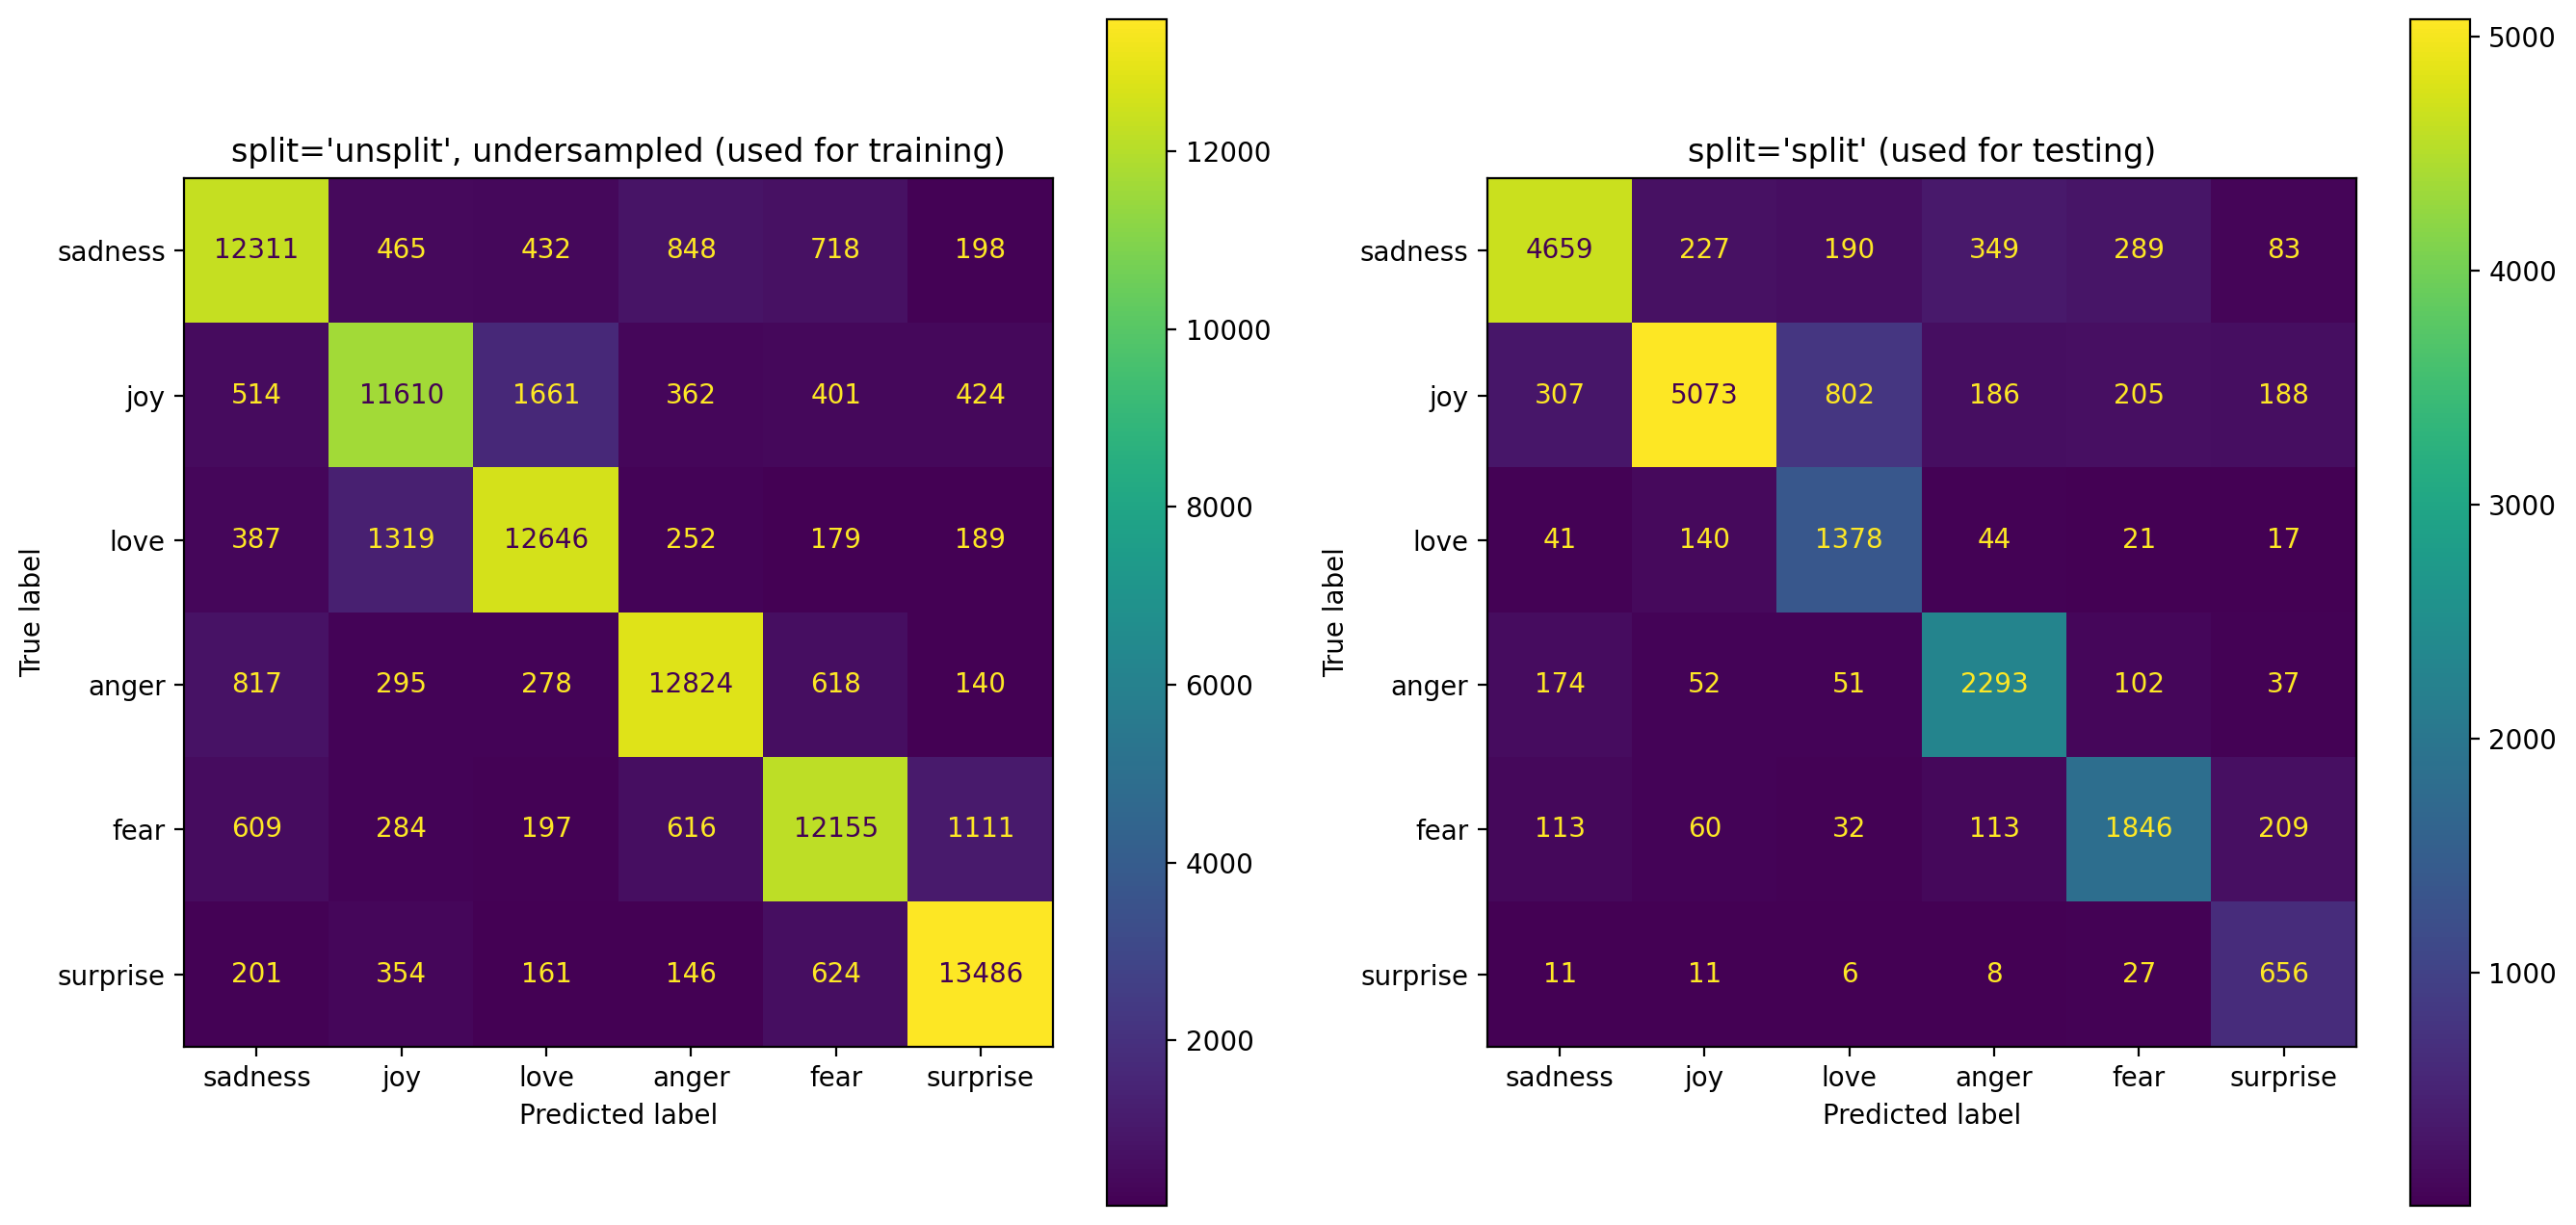

In [31]:
from softprompt.metrics.evaluator import MulticlassEvaluator
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

evaluator = MulticlassEvaluator(average='macro')
unsplit_metrics = evaluator(
    y_unsplit_undersampled, lg.predict_proba(X_unsplit_undersampled)
)
split_metrics = evaluator(
    y_split, lg.predict_proba(X_split)
)

# classification metrics computed on unsplit data (used for training)
clf_report_unsplit_downsampled = classification_report(
    y_unsplit_undersampled,
    lg.predict(X_unsplit_undersampled),
    target_names=('sadness', 'joy', 'love', 'anger', 'fear', 'surprise'),
    digits=4,
    output_dict=False,
)
print("Unsplit (Train) (downsampled):")
print(clf_report_unsplit_downsampled)

# classification metrics computed on split data (for testing generalization performance)
clf_report_split = classification_report(
    y_split,
    lg.predict(X_split),
    target_names=('sadness', 'joy', 'love', 'anger', 'fear', 'surprise'),
    digits=4,
    output_dict=False,
)
print("Split (Test):")
print(clf_report_split)

# Confusion matrix
labels = ('sadness', 'joy', 'love', 'anger', 'fear', 'surprise')
common_kwargs = dict(display_labels=labels, normalize=None, values_format="d", colorbar=True) 
fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=200)

ConfusionMatrixDisplay.from_estimator(lg, X_unsplit_undersampled, y_unsplit_undersampled, ax=axes[0], **common_kwargs)
axes[0].set_title("split='unsplit', undersampled (used for training)")

ConfusionMatrixDisplay.from_estimator(lg, X_split, y_split, ax=axes[1], **common_kwargs)
axes[1].set_title("split='split' (used for testing)")

plt.show(fig)

#### 3-1-2. Fit model on different proportions
- No regularization

In [33]:
size_to_acc = {}

ratios = (0.01, 0.05, 0.1, 0.25, 0.5, 1.0)
subsample_sizes = [int(len(y_unsplit_undersampled) * r) for r in ratios]

for i, subsample_size in enumerate(subsample_sizes):

    print(">>No Regularization")
    print(f">> Sample size: {subsample_size:>6,} (ratio={ratios[i]})")

    eval_result = evaluate_lg(
        X_unsplit_undersampled, y_unsplit_undersampled, X_split, y_split,
        subsample_size=subsample_size,
        bootstrap=True,
        n_trials=5,
        penalty=None
    )

    train_acc, test_acc = \
        eval_result['train_accuracy'], eval_result['test_accuracy']
    train_f1, test_f1 = \
        eval_result['train_f1'], eval_result['test_f1']

    size_to_acc[subsample_size] = eval_result

    print("\t Train acc = {:.4f} ({:.4f})".format(*train_acc))
    print("\t  Test acc = {:.4f} ({:.4f})".format(*test_acc))
    print("\t Train  f1 = {:.4f} ({:.4f})".format(*train_f1))
    print("\t  Test  f1 = {:.4f} ({:.4f})".format(*test_f1))

>>No Regularization
>> Sample size:    898 (ratio=0.01)
	 Train acc = 1.0000 (0.0000)
	  Test acc = 0.6001 (0.0130)
	 Train  f1 = 1.0000 (0.0000)
	  Test  f1 = 0.5644 (0.0125)
>>No Regularization
>> Sample size:  4,491 (ratio=0.05)
	 Train acc = 0.9989 (0.0004)
	  Test acc = 0.6575 (0.0081)
	 Train  f1 = 0.9989 (0.0004)
	  Test  f1 = 0.6204 (0.0068)
>>No Regularization
>> Sample size:  8,983 (ratio=0.1)
	 Train acc = 0.9974 (0.0008)
	  Test acc = 0.6805 (0.0043)
	 Train  f1 = 0.9974 (0.0009)
	  Test  f1 = 0.6438 (0.0060)
>>No Regularization
>> Sample size: 22,458 (ratio=0.25)
	 Train acc = 0.9156 (0.0078)
	  Test acc = 0.7268 (0.0078)
	 Train  f1 = 0.9155 (0.0078)
	  Test  f1 = 0.6906 (0.0078)
>>No Regularization
>> Sample size: 44,916 (ratio=0.5)
	 Train acc = 0.8682 (0.0025)
	  Test acc = 0.7638 (0.0026)
	 Train  f1 = 0.8680 (0.0026)
	  Test  f1 = 0.7293 (0.0034)
>>No Regularization
>> Sample size: 89,832 (ratio=1.0)
	 Train acc = 0.8516 (0.0020)
	  Test acc = 0.7799 (0.0018)
	 Train

### 3-2. With Regularization
- `LogisticRegressionCV(Cs=10, cv=5, penalty='l2')`

#### 3-2-1. Fit model on the whole undersampled data

#### 3-2-2. Fit model on different proportions

In [34]:
size_to_acc = {}

ratios = (0.01, 0.05, 0.1, 0.25, 0.5, 1.0)
subsample_sizes = [int(len(y_unsplit_undersampled) * r) for r in ratios]

for i, subsample_size in enumerate(subsample_sizes):

    print(">>No Regularization")
    print(f">> Sample size: {subsample_size:>6,} (ratio={ratios[i]})")

    eval_result = evaluate_lg(
        X_unsplit_undersampled, y_unsplit_undersampled, X_split, y_split,
        subsample_size=subsample_size,
        bootstrap=True,
        n_trials=5,
        penalty='l2',
    )

    train_acc, test_acc = \
        eval_result['train_accuracy'], eval_result['test_accuracy']
    train_f1, test_f1 = \
        eval_result['train_f1'], eval_result['test_f1']

    size_to_acc[subsample_size] = eval_result

    print("\t Train acc = {:.4f} ({:.4f})".format(*train_acc))
    print("\t  Test acc = {:.4f} ({:.4f})".format(*test_acc))
    print("\t Train  f1 = {:.4f} ({:.4f})".format(*train_f1))
    print("\t  Test  f1 = {:.4f} ({:.4f})".format(*test_f1))

>>No Regularization
>> Sample size:    898 (ratio=0.01)
	 Train acc = 0.9991 (0.0009)
	  Test acc = 0.6287 (0.0043)
	 Train  f1 = 0.9991 (0.0009)
	  Test  f1 = 0.5899 (0.0052)
>>No Regularization
>> Sample size:  4,491 (ratio=0.05)
	 Train acc = 0.9597 (0.0033)
	  Test acc = 0.7020 (0.0045)
	 Train  f1 = 0.9597 (0.0033)
	  Test  f1 = 0.6660 (0.0045)
>>No Regularization
>> Sample size:  8,983 (ratio=0.1)
	 Train acc = 0.9160 (0.0101)
	  Test acc = 0.7314 (0.0023)
	 Train  f1 = 0.9158 (0.0103)
	  Test  f1 = 0.6959 (0.0023)
>>No Regularization
>> Sample size: 22,458 (ratio=0.25)
	 Train acc = 0.8287 (0.0038)
	  Test acc = 0.7534 (0.0014)
	 Train  f1 = 0.8284 (0.0037)
	  Test  f1 = 0.7192 (0.0009)
>>No Regularization
>> Sample size: 44,916 (ratio=0.5)
	 Train acc = 0.8278 (0.0025)
	  Test acc = 0.7685 (0.0018)
	 Train  f1 = 0.8274 (0.0024)
	  Test  f1 = 0.7348 (0.0017)
>>No Regularization
>> Sample size: 89,832 (ratio=1.0)
	 Train acc = 0.8378 (0.0074)
	  Test acc = 0.7831 (0.0032)
	 Train

## 4. Diversity Metrics

In [ ]:
labels = y_